In [16]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

con = duckdb.connect("../dev.duckdb")

df = con.execute("""
    select
        month,
        segment,
        authorized_eur,
        refunded_eur,
        reversed_eur,
        net_revenue_eur,
        mom_change
    from fct_monthly_revenue
    where month < '2026-01' 
    order by month, segment

""").df()

df["month"] = pd.to_datetime(df["month"])

In [19]:
def plot_metric(df, metric, title, ylabel):
    plt.figure(figsize=(12, 6))

    for segment, group in df.groupby("segment"):
        plt.plot(
            group["month"],
            group[metric],
            marker="o",
            label=segment
        )

    plt.xlabel("Month")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df

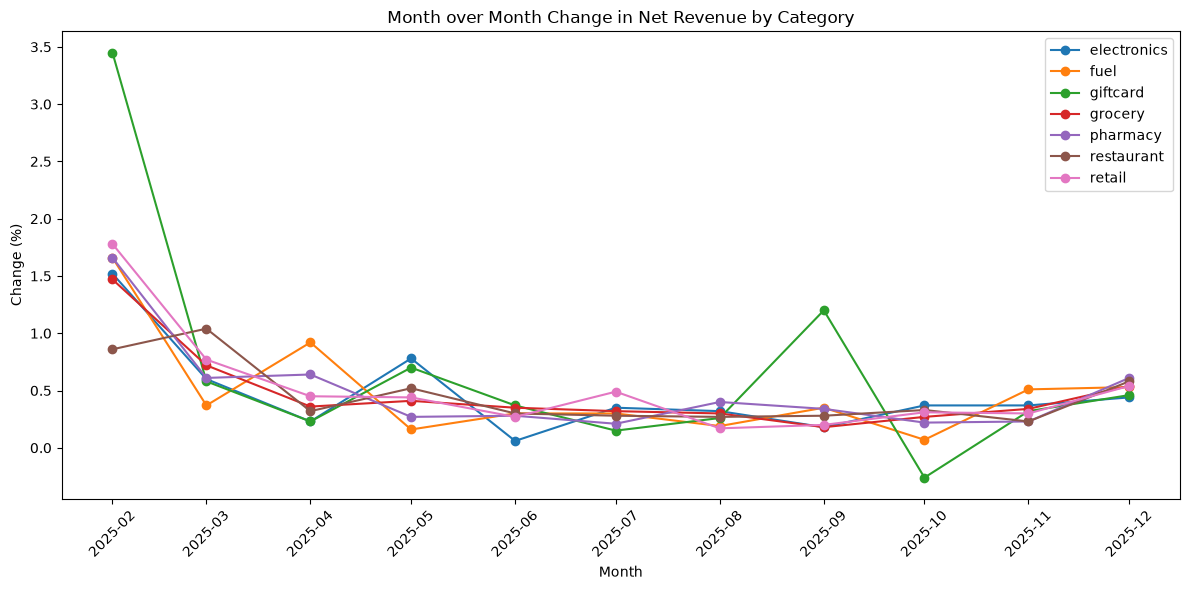

In [20]:
monthly_change_analysis = plot_metric(df, "mom_change", "Month over Month Change in Net Revenue by Category", "Change (%)")

In [21]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

def plot_activation_mom(db_path):
    con = duckdb.connect(db_path)

    df = con.execute("""
        SELECT
            signup_month,
            mom_change
        FROM fct_wallet_activation
        ORDER BY signup_month
    """).df()

    con.close()

    df["signup_month"] = pd.to_datetime(df["signup_month"])

    plt.figure(figsize=(12, 6))
    plt.plot(
        df["signup_month"],
        df["mom_change"] * 100,
        marker="o"
    )

    plt.axhline(0, linestyle="--", linewidth=1, color="black")
    plt.xlabel("Signup Month")
    plt.ylabel("MoM Activation Rate Change (Percentage Points)")
    plt.title("Month-over-Month Change in 30-Day Wallet Activation Rate")
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df

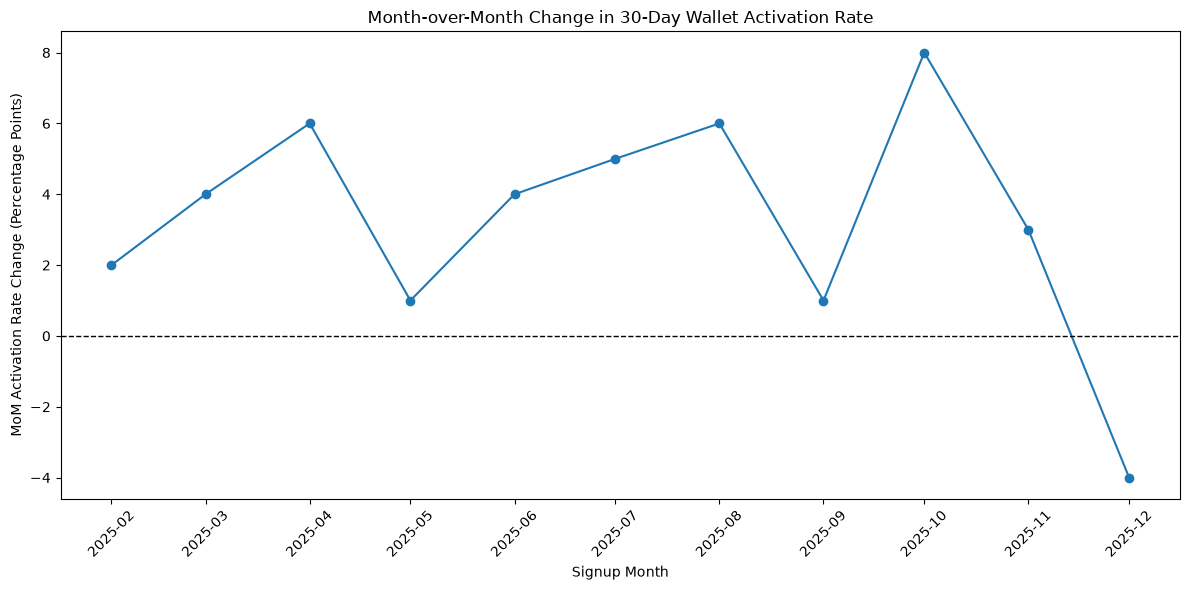

In [9]:
activation_rate_analysis = plot_activation_mom("../dev.duckdb")

In [22]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd


def plot_wallet_status_rates(db_path):
    con = duckdb.connect(db_path)

    df = con.execute("""
        select
            signup_month,
            active_rate,
            churned_rate,
            blocked_rate
        from fct_wallet_activation
        order BY signup_month
    """).df()

    con.close()

    df["signup_month"] = pd.to_datetime(df["signup_month"])

    # Calculate historical baselines
    active_mean = df["active_rate"].mean()
    active_sd = df["active_rate"].std()
    active_threshold = active_mean - active_sd

    churned_mean = df["churned_rate"].mean()
    churned_sd = df["churned_rate"].std()
    churned_threshold = churned_mean + churned_sd

    blocked_mean = df["blocked_rate"].mean()
    blocked_sd = df["blocked_rate"].std()
    blocked_threshold = blocked_mean + blocked_sd

    # Flag anomalous cohorts
    flagged_active = df[df["active_rate"] < active_threshold]
    flagged_churned = df[df["churned_rate"] > churned_threshold]
    flagged_blocked = df[df["blocked_rate"] > blocked_threshold]

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(
        df["signup_month"],
        df["active_rate"] * 100,
        marker="o",
        label="Active"
    )

    plt.plot(
        df["signup_month"],
        df["churned_rate"] * 100,
        marker="o",
        label="Churned"
    )

    plt.plot(
        df["signup_month"],
        df["blocked_rate"] * 100,
        marker="o",
        label="Blocked"
    )

    # Threshold lines
    plt.axhline(
        active_threshold * 100,
        linestyle="--",
        linewidth=1,
        label=f"Active -1 SD ({active_threshold:.1%})"
    )

    plt.axhline(
        churned_threshold * 100,
        linestyle="--",
        linewidth=1,
        label=f"Churned +1 SD ({churned_threshold:.1%})"
    )

    plt.axhline(
        blocked_threshold * 100,
        linestyle="--",
        linewidth=1,
        label=f"Blocked +1 SD ({blocked_threshold:.1%})"
    )

    # Highlight anomalous Active points
    plt.scatter(
        flagged_active["signup_month"],
        flagged_active["active_rate"] * 100,
        s=120,
        zorder=5
    )

    # Highlight anomalous Churned points
    plt.scatter(
        flagged_churned["signup_month"],
        flagged_churned["churned_rate"] * 100,
        s=120,
        zorder=5
    )

    # Highlight anomalous Blocked points
    plt.scatter(
        flagged_blocked["signup_month"],
        flagged_blocked["blocked_rate"] * 100,
        s=120,
        zorder=5
    )

    plt.xlabel("Signup Month")
    plt.ylabel("Rate (%)")
    plt.title("Wallet Status Risk Indicators by Signup Cohort")
    plt.legend()
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df

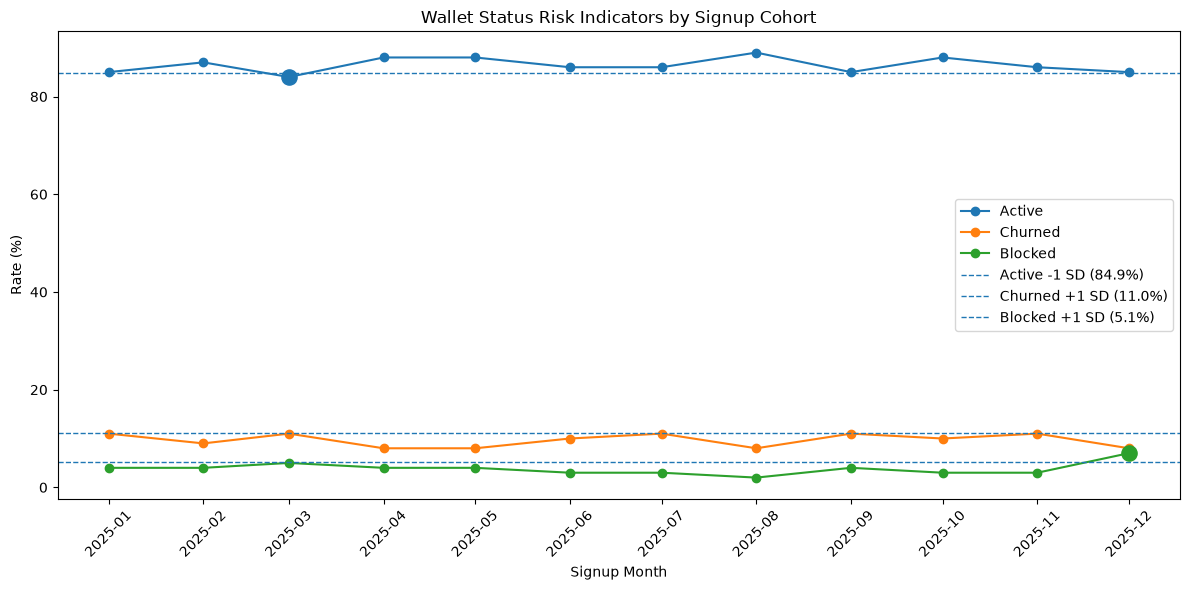

In [23]:
activity_analysis = plot_wallet_status_rates("../dev.duckdb")